### Business Objective

Customer churn is a major concern in the telecom industry.

This project aims to:
- Predict whether a customer will churn
- Identify high-risk customers
- Segment customers for targeted retention strategies

In [68]:
import pandas as pd

file_path = r"C:\Users\User\Downloads\WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(file_path)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Dataset Overview

The dataset contains customer demographics, service usage, and billing details.

Target variable:
- **Churn** → Indicates whether a customer left the company

In [69]:
# Remove unnecessary column
df = df.drop('customerID', axis=1)

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Fill missing values
df.fillna({"TotalCharges": df["TotalCharges"].mean()}, inplace=True)
df.isnull().sum()

### Data Cleaning

- Removed `customerID` (not useful for prediction)
- Converted `TotalCharges` to numeric
- Missing values replaced with mean

This ensures clean and consistent data for modeling.

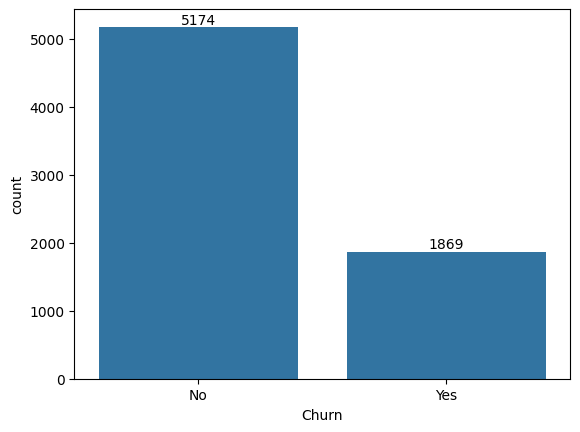

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.countplot(x='Churn', data=df)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center', va='bottom'
    )

plt.show()

### Churn Distribution

👉 Insight:
- The dataset is slightly imbalanced
- This means accuracy alone is not enough — recall is important

In [71]:
df = pd.get_dummies(df, drop_first=True).astype(int)

df['Churn'] = df['Churn_Yes']
df = df.drop('Churn_Yes', axis=1)


### Feature Engineering

- Converted categorical variables into numeric using one-hot encoding
- Converted churn into binary format (0/1)

This prepares data for machine learning models.

In [72]:
from sklearn.model_selection import train_test_split

X = df.drop("Churn", axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Train-Test Split

- 80% training, 20% testing
- Stratification ensures balanced churn distribution

In [74]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

### Feature Scaling

Standardization ensures all features are on the same scale, improving model performance.

In [75]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### Model Selection

Logistic Regression is used due to:
- Simplicity
- Interpretability
- Strong baseline performance

In [76]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8062455642299503
Confusion Matrix:
 [[924 111]
 [162 212]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



### Model Performance

- Accuracy shows overall performance  
- Recall is critical to identify churn customers  

👉 Business Focus: Catch as many churn customers as possible

In [77]:
importance = pd.DataFrame({
    "feature": X.columns,
    "Coefficient": model.coef_[0]
})

importance = importance.sort_values(by="Coefficient", ascending=False)
importance.head(10)

,feature,Coefficient
10,InternetService_Fiber optic,0.731140
3,TotalCharges,0.492686
23,StreamingMovies_Yes,0.240626
21,StreamingTV_Yes,0.239318
9,MultipleLines_Yes,0.207345
28,PaymentMethod_Electronic check,0.182210
26,PaperlessBilling_Yes,0.182042
0,SeniorCitizen,0.052926
17,DeviceProtection_Yes,0.044703
29,PaymentMethod_Mailed check,0.033262


### Key Drivers of Churn

👉 Features with high positive coefficients increase churn probability  
👉 Features with negative coefficients reduce churn  

This helps understand customer behavior.

In [78]:
df["TenureGroup"] = pd.cut(df["tenure"],
                          bins=[0,12,24,48,72],
                          labels=["0-1yr","1-2yr","2-4yr","4-6yr"])

df["SpendingLevel"] = pd.qcut(df["MonthlyCharges"], 3,
                             labels=["Low","Medium","High"])

df['CLV'] = df['tenure'] * df['MonthlyCharges']

### Customer Segmentation

- Customers grouped by tenure and spending
- CLV (Customer Lifetime Value) created

👉 Helps in business targeting strategies

In [79]:
pd.crosstab(df["TenureGroup"], df["Churn"], normalize="index")
pd.crosstab(df["SpendingLevel"], df["Churn"], normalize="index")

Churn,0,1
SpendingLevel,,
Low,0.836168,0.163832
Medium,0.704724,0.295276
High,0.659420,0.340580


### Insights

- New customers churn more frequently  
- High spending customers show different churn patterns  

👉 Early engagement is critical

In [ ]:
df["Churn_Prob"] = model.predict_proba(X)[:,1]

df["Risk_Level"] = pd.cut(df["Churn_Prob"],
                         bins=[0,0.3,0.6,1],
                         labels=["Low Risk","Medium Risk","High Risk"])

### Risk Segmentation

Customers categorized into:
- Low Risk  
- Medium Risk  
- High Risk  

👉 Enables targeted retention campaigns

In [81]:
pd.crosstab(df["Risk_Level"], df["Churn"], normalize='index')

df["Customer_Type"] = df["Risk_Level"].astype(str) + " - " + df["SpendingLevel"].astype(str)

pd.crosstab(df["Customer_Type"], df["Churn"])

Churn,0,1
Customer_Type,,
High Risk - High,1540,750
High Risk - Low,1800,223
High Risk - Medium,1564,497
Low Risk - High,7,49
Low Risk - Low,207,167
Low Risk - Medium,45,177
Medium Risk - Low,9,5
Medium Risk - Medium,2,1


### Customer Profiling

Combining risk and spending gives deeper insights into:
- High-value customers at risk  
- Low-value customers likely to churn  

👉 Helps prioritize business actions

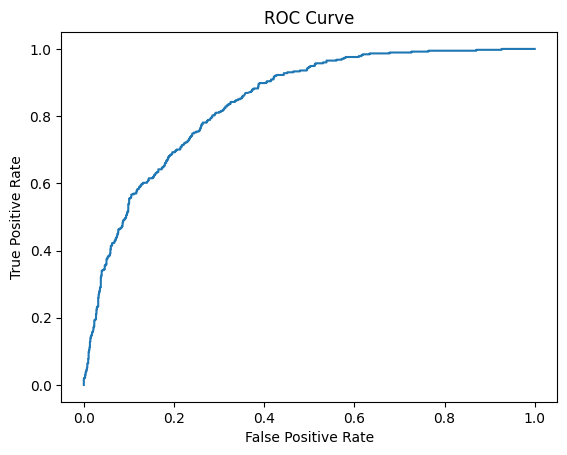

AUC: 0.8414916427704151


In [82]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

import matplotlib.pyplot as plt

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

print("AUC:", roc_auc)

### Model Evaluation (AUC)

- AUC measures model’s ability to distinguish classes  
- Higher AUC = better model performance  

In [83]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))

RF Accuracy: 0.78708303761533


In [84]:
from sklearn.metrics import classification_report

print("Logistic Regression\n", classification_report(y_test, y_pred))
print("Random Forest\n", classification_report(y_test, y_pred_rf))

Logistic Regression
               precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

Random Forest
               precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.50      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



### Model Comparison

- Logistic Regression → Interpretable  
- Random Forest → Better performance (in many cases)  

👉 Choose model based on business need:
- Interpretability vs Accuracy

### Final Insights

- Customers with low tenure are more likely to churn  
- Spending behavior influences churn patterns  
- High-risk customers can be identified using probability scores  

### Business Recommendations

- Target high-risk customers with retention offers  
- Focus on onboarding new customers  
- Provide loyalty benefits for long-term customers  